# Lecture 10, Notebook 12: Krusell–Smith with all-in-one deep learning

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §6.6 (Alternative deep-learning approaches to Krusell--Smith)  
**Notebook role:** extension  
**Author:** Simon Scheidegger  

---

In [1]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Krusell-Smith with All-in-One Deep Learning

Classroom-scale deep-learning solver for the Krusell-Smith (1998) economy.

**References:** Maliar, Maliar & Winant (2021), *Journal of Monetary Economics* 122, 76-101 (method); Krusell & Smith (1998), *Journal of Political Economy* 106(5) (model).

### What this notebook does

This notebook solves the canonical Krusell-Smith (1998) heterogeneous-agent model -- a continuum of ex-ante identical, infinitely-lived agents facing idiosyncratic employment risk and aggregate productivity shocks -- by stochastic gradient descent on the Euler-equation residual.  The network parameterises the agent's savings policy as a function of $(k, \varepsilon, \bar K, a)$, and we train it directly against the structural Euler equation rather than iterating on a separate forecasting rule.

### Pedagogical goals

1. The DEQN template from Chapter 2 (loss = squared equilibrium residual, network outputs policies, SGD) transfers verbatim to a full heterogeneous-agent problem.
2. Reproduce the **approximate aggregation** insight of Krusell & Smith (1998): the mean of the wealth distribution is a nearly sufficient statistic for aggregate prices.  We regress next-period mean capital on current mean capital and confirm $R^2 > 0.99$ in both aggregate states (and typically $R^2 > 0.999$ in the good state).
3. Verify that a single panel-trained policy network matches the canonical KS log-utility benchmark on a CPU in roughly ten minutes.


## 1. Imports and reproducibility

In [2]:
# Core scientific Python
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow 2.x with Keras
import tensorflow as tf
from tensorflow import keras

# Reproducibility -- reseed from the cell-1 SEED constant.
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Seed:", SEED)
plt.rcParams["font.size"] = 12


2026-05-12 13:49:58.645463: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-12 13:49:58.646318: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 13:49:58.650490: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-12 13:49:58.661066: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778586598.678087   81062 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778586598.68

TensorFlow version: 2.19.0
Seed: 0


## 2. Model parameters

Standard Krusell–Smith (1998) *quarterly* calibration with **log utility**
(CRRA with $\sigma = 1$), which admits the particularly clean Euler
equation $1/c = \beta\,\mathbb{E}[(1+r'-\delta)/c']$.

| symbol     | meaning                                            | value |
|:-----------|:---------------------------------------------------|:-----:|
| $\beta$    | discount factor (quarterly)                        | 0.99  |
| $\alpha$   | capital share in Cobb–Douglas production           | 0.36  |
| $\delta$   | depreciation rate (quarterly)                      | 0.025 |
| $\bar{l}$  | employed-agent labor endowment (labor normalisation) | $1/(1-u_{\text{ss}})$ |
| $z_g, z_b$ | aggregate TFP in good / bad state                  | 1.01, 0.99 |
| $u_g, u_b$ | unemployment rate in good / bad state              | 0.04, 0.10 |
| $N$        | agents in simulated panel (`smoke`/`teaching`/`production`) | 100 / 300 / 1000 |

### What does the deterministic steady state look like?

Ignoring shocks, the deterministic steady state of log utility with
$\beta(1+r-\delta) = 1$ gives

$$
r^* = \beta^{-1} - 1 + \delta \approx 0.0351, \qquad
\frac{K^*}{L^*} = \left(\frac{\alpha}{r^*}\right)^{\frac{1}{1-\alpha}} \approx 38, \qquad
K^* = \frac{K^*}{L^*}\,L^* \approx 35
$$

with $L^* \approx 0.93$ average labor.  The level $K^* \approx 35$ — printed
below as `K_SS` — is the ballpark we expect $\bar K$ to fluctuate around in
the stochastic ergodic distribution.

In [3]:
# --- Preferences ---
beta   = tf.constant(0.99, dtype=tf.float32)
sigma  = tf.constant(1.0,  dtype=tf.float32)    # log utility

# --- Technology ---
alpha  = tf.constant(0.36, dtype=tf.float32)
delta  = tf.constant(0.025, dtype=tf.float32)

# --- Aggregate and idiosyncratic shock levels ---
z_levels = tf.constant([0.99, 1.01], dtype=tf.float32)   # (bad, good)
u_rates  = tf.constant([0.10, 0.04], dtype=tf.float32)   # (bad, good)

# Steady-state average unemployment (used for labor normalisation)
u_ss   = 0.07
l_bar  = tf.constant(1.0 / (1.0 - u_ss), dtype=tf.float32)

# --- Panel size, dispatched on RUN_MODE ---
_PANEL = {"smoke": 100, "teaching": 300, "production": 1000}[RUN_MODE]
N_AGENTS = _PANEL

# --- Deterministic steady-state k (for panel initialisation) ---
r_ss_det = 1.0/float(beta.numpy()) - 1.0 + float(delta.numpy())
K_ss_det = ((float(alpha.numpy()) / r_ss_det) ** (1.0/(1.0-float(alpha.numpy()))))
# Adjust for L_ss (avg employed):
L_ss = 1.0 - u_ss
K_SS = K_ss_det * L_ss          # pulls the SS down a bit via the production function
print(f"log-utility KS calibration: β={float(beta.numpy())}, α={float(alpha.numpy())}, δ={float(delta.numpy())}")
print(f"deterministic steady-state K ≈ {K_SS:.2f}")

# --- Capital domain ---
# Used for state-space sampling in Phase A.  Covers the ergodic range + margin.
K_MIN = 0.5 * K_SS
K_MAX = 1.5 * K_SS
k_min = tf.constant(1e-3, dtype=tf.float32)   # avoid log(0)
k_ind_min = 0.2 * K_SS                         # individual k sampled in Phase A
k_ind_max = 4.0 * K_SS                         # (wide enough to cover realistic holdings)
print(f"training domain: K̄ ∈ [{K_MIN:.2f}, {K_MAX:.2f}],  k ∈ [{k_ind_min:.2f}, {k_ind_max:.2f}]")


log-utility KS calibration: β=0.9900000095367432, α=0.36000001430511475, δ=0.02500000037252903
deterministic steady-state K ≈ 35.33
training domain: K̄ ∈ [17.67, 53.00],  k ∈ [7.07, 141.32]


E0000 00:00:1778586601.354722   81062 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778586601.356307   81062 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 3. Shock transition matrix

Following Krusell & Smith (1998), the joint aggregate–idiosyncratic shock
$(a,\varepsilon) \in \{\text{bad},\text{good}\}\times\{\text{unempl.},\text{empl.}\}$
evolves as a first-order Markov chain.  Numbers below are the standard
KS calibration (Table 1 of KS 1998) in which:

- Each aggregate state lasts on average $8$ quarters, $P(a'=a|a) = 0.875$.
- Conditional unemployment rate in state $a'$ equals $u_{a'}$.
- Unemployment spells last on average ~2.4 quarters in good times and ~4
  quarters in bad times.

In [4]:
# Aggregate-state transition
P_agg = np.array([
    [0.875, 0.125],    # bad  -> (bad, good)
    [0.125, 0.875],    # good -> (bad, good)
], dtype=np.float32)

# Conditional idiosyncratic transition P(eps' | a, a', eps)
# Shape (a, a', eps, eps'); rows over eps' sum to 1.
P_eps = np.zeros((2, 2, 2, 2), dtype=np.float32)

P_eps[0, 0] = [[0.525, 0.475],
               [0.350, 0.650]]            # bad  -> bad
P_eps[0, 1] = [[0.093, 0.907],
               [0.038, 0.962]]            # bad  -> good
P_eps[1, 0] = [[0.840, 0.160],
               [0.200, 0.800]]            # good -> bad
P_eps[1, 1] = [[0.292, 0.708],
               [0.042, 0.958]]            # good -> good

assert np.allclose(P_eps.sum(axis=-1), 1.0, atol=1e-6)

P_agg_tf = tf.constant(P_agg)
P_eps_tf = tf.constant(P_eps)
print("Aggregate transition matrix:\n", P_agg)


Aggregate transition matrix:
 [[0.875 0.125]
 [0.125 0.875]]


## 4. Prices and budget constraint

Under Cobb–Douglas production the firm's first-order conditions give

$$
w(\bar K, a) = (1-\alpha) z(a) \bar K^{\alpha} L^{-\alpha},
\qquad
r(\bar K, a) = \alpha z(a) \bar K^{\alpha - 1} L^{1-\alpha},
$$

with $L = 1 - u(a)$.  The individual budget is

$$
c + k' = \underbrace{w\,\bar l\,\varepsilon + (1 + r - \delta)\,k}_{=: y,\ \text{cash on hand}}.
$$

We take $\bar l \varepsilon = \bar l$ when employed and $\bar l \varepsilon = 0$
when unemployed (this is the KS convention: unemployed agents get zero
labor income, no unemployment benefits).

In [5]:

@tf.function
def prices(K_agg, a_idx):
    '''Aggregate prices w, r at (K̄, a).

    K_agg: () tf.float32 scalar
    a_idx: () int32 scalar; 0 = bad, 1 = good.
    '''
    z = tf.gather(z_levels, a_idx)
    u = tf.gather(u_rates,  a_idx)
    L = 1.0 - u
    w = (1.0 - alpha) * z * tf.pow(K_agg, alpha)        * tf.pow(L, -alpha)
    r = alpha         * z * tf.pow(K_agg, alpha - 1.0)  * tf.pow(L, 1.0 - alpha)
    return w, r

@tf.function
def cash_on_hand_panel(k, eps_float, w, r):
    '''Cash on hand for a panel of agents.  Shapes: k,eps_float (N,); w,r (). Returns (N,).'''
    return w * l_bar * eps_float + (1.0 + r - delta) * k


## 5. Policy network

We parameterise the **consumption share** policy

$$
\pi_\rho : (k, \varepsilon, \bar K, a) \mapsto \phi \in (0, 1),
$$

with consumption $c = \phi y$ and savings $k' = (1-\phi) y$.  The sigmoid
output ensures $0 \leq c \leq y$, and the saved fraction is automatically
non-negative, which enforces the borrowing constraint by construction.

### Inputs to the network

- `k` — individual capital (log-normalised: $\log(k / K^*)$).
- `eps` — 2-dim one-hot for (unempl., empl.).
- `K` — aggregate capital (log-normalised).
- `a` — 2-dim one-hot for (bad, good).

Log-normalisation gives stable inputs to the network over the whole
training range and empirically improves convergence by a lot.

Architecture: 2 hidden layers of 64 Swish units, sigmoid output
(same family as every other DEQN / NAS network in this course).

In [6]:

class LogNormaliseLayer(keras.layers.Layer):
    '''Compute log(max(x, eps) / K_ss) as a Keras-native layer.
    Keras Functional models require ops in the namespace keras.ops or keras.layers.
    '''
    def __init__(self, K_ss, eps=1e-3, **kw):
        super().__init__(**kw)
        self.K_ss = float(K_ss)
        self.eps  = float(eps)
    def call(self, x):
        import tensorflow as tf
        return tf.math.log(tf.maximum(x, self.eps) / self.K_ss)

def build_policy_network():
    k_in   = keras.Input(shape=(1,), name="k")
    eps_in = keras.Input(shape=(2,), name="eps")
    K_in   = keras.Input(shape=(1,), name="K")
    a_in   = keras.Input(shape=(2,), name="a")

    # Log-normalise the continuous inputs around the deterministic SS
    k_feat = LogNormaliseLayer(K_SS, name="log_k_over_Kss")(k_in)
    K_feat = LogNormaliseLayer(K_SS, name="log_K_over_Kss")(K_in)

    h = keras.layers.concatenate([k_feat, eps_in, K_feat, a_in])
    h = keras.layers.Dense(64, activation="swish")(h)
    h = keras.layers.Dense(64, activation="swish")(h)
    out = keras.layers.Dense(1, activation="sigmoid", name="phi")(h)
    return keras.Model([k_in, eps_in, K_in, a_in], out)

policy_net = build_policy_network()
policy_net.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ k (InputLayer)      │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ K (InputLayer)      │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_k_over_Kss      │ (None, 1)         │          0 │ k[0][0]           │
│ (LogNormaliseLayer) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eps (InputLayer)    │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_K_over_Kss      │ (None, 1)         │          0 │ K[0][0]           │
│ (LogNormaliseLayer) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ a (InputLayer)      │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 6)         │          0 │ log_k_over_Kss[0… │
│ (Concatenate)       │                   │            │ eps[0][0],        │
│                     │                   │            │ log_K_over_Kss[0… │
│                     │                   │            │ a[0][0]           │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phi (Dense)         │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Mapping policy network to consumption and savings

Given a batch of $(k_i, \varepsilon_i)$ states and an aggregate $(\bar K, a)$,
we compute consumption and next-period capital for every agent.

In [7]:

def onehot2(idx_tensor, n=2):
    '''Create one-hot tensor; works on either Python int or tf tensor of ints.'''
    return tf.one_hot(idx_tensor, depth=n, dtype=tf.float32)

def apply_policy(k, eps_int, K_agg, a_idx):
    '''Apply the policy network to a batch of individual states + single aggregate state.

    k:       (N,)   tf.float32, individual capital
    eps_int: (N,)   tf.int32, employment indicator (0,1)
    K_agg:   ()     tf.float32, aggregate capital
    a_idx:   ()     tf.int32,  aggregate state index

    Returns phi, c, k_next, y, w, r
    '''
    w, r = prices(K_agg, a_idx)
    eps_float = tf.cast(eps_int, tf.float32)
    y = cash_on_hand_panel(k, eps_float, w, r)

    N = tf.shape(k)[0]
    k_col    = tf.reshape(k, (-1, 1))
    eps_1hot = onehot2(eps_int)
    K_col    = tf.fill([N, 1], K_agg)
    a_1hot   = tf.tile(tf.reshape(onehot2(a_idx), (1, 2)), [N, 1])

    phi = policy_net([k_col, eps_1hot, K_col, a_1hot], training=True)
    phi = tf.squeeze(phi, axis=-1)
    # strict interior to avoid log(0) / div-by-0 in the Euler residual
    phi = tf.clip_by_value(phi, 1e-3, 1.0 - 1e-3)

    c      = phi * y
    k_next = (1.0 - phi) * y
    return phi, c, k_next, y, w, r


## 7. Euler-equation residual (the loss)

For log utility, the Euler equation is

$$
\frac{1}{c_t} \;=\; \beta\,\mathbb{E}_t\!\left[\frac{1 + r_{t+1} - \delta}{c_{t+1}}\right].
$$

Because the aggregate and idiosyncratic shocks each take only two values,
the expectation is a *deterministic* sum over 4 $(a',\varepsilon')$ pairs,
weighted by the joint transition probability.  **No Monte Carlo needed.**
This is the cleanest version of the MMW "all-in-one integration operator"
and is numerically stable by construction.

### Relative Euler error

We report the **relative Euler error** (as in the IRBC chapter of the
script):

$$
e^{\text{REE}}_i = \beta\,c_i\,\mathbb{E}_t\!\left[\frac{1+r'-\delta}{c'_i}\right] - 1.
$$

A residual of $10^{-3}$ means the agent's Euler equation is violated by
0.1% of consumption, independent of units.

### Important caveat: aggregate $\bar K_{t+1}$

In a heterogeneous-agent model, tomorrow's aggregate capital $\bar K'$ is
endogenous — it equals the mean of $k'_i$ across agents.  In the
all-in-one DL formulation, we take $\bar K' = \frac{1}{N}\sum_i k'_i$
using the network's own savings decisions, so the aggregate law of
motion is automatically consistent with the individual policy.  No
separate "law of motion" is fitted.

In [8]:

def euler_residual(k_panel, eps_int, K_agg, a_idx):
    '''Return (loss, ree, c, k_next, K_next) for a batch / panel.'''
    # --- today ---
    phi, c, k_next, y, w, r = apply_policy(k_panel, eps_int, K_agg, a_idx)

    # Next-period aggregate capital: average of the network's own savings
    K_next = tf.reduce_mean(k_next)

    # --- tomorrow: exact sum over (a', eps') pairs ---
    # Joint conditional prob of (a', eps') given (a, eps_i), for each agent i
    # P_eps_tf[a_idx, :, eps_i, :]  has shape (2 a', 2 eps'); we stack over agents.
    pe_stack = tf.gather(P_eps_tf[a_idx], eps_int, axis=1)       # (2 a', N, 2 eps')
    pe_stack = tf.transpose(pe_stack, [1, 0, 2])                 # (N, 2 a', 2 eps')
    P_ap     = P_agg_tf[a_idx]                                   # (2,) over a'
    prob     = pe_stack * tf.reshape(P_ap, (1, 2, 1))            # (N, 2 a', 2 eps')

    # Accumulate E[(1 + r' - delta) / c'] across (a', eps')
    EMU = tf.zeros_like(c)
    for a_next in range(2):
        w_n, r_n = prices(K_next, a_next)
        for eps_next_val in range(2):
            eps_next_vec = tf.fill(tf.shape(eps_int), eps_next_val)
            eps_n_float  = tf.cast(eps_next_vec, tf.float32)
            y_n = cash_on_hand_panel(k_next, eps_n_float, w_n, r_n)

            N = tf.shape(k_next)[0]
            k_col    = tf.reshape(k_next, (-1, 1))
            eps_1hot = onehot2(eps_next_vec)
            K_col    = tf.fill([N, 1], K_next)
            a_1hot   = tf.tile(tf.reshape(onehot2(a_next), (1, 2)), [N, 1])
            phi_n = tf.squeeze(
                policy_net([k_col, eps_1hot, K_col, a_1hot], training=True), axis=-1)
            phi_n = tf.clip_by_value(phi_n, 1e-3, 1.0 - 1e-3)
            c_n = phi_n * y_n

            contrib = (1.0 + r_n - delta) / c_n                            # (N,)
            weight  = prob[:, a_next, eps_next_val]                         # (N,)
            EMU += weight * contrib

    # Relative Euler error (unit-free)
    ree = beta * c * EMU - 1.0
    loss = tf.reduce_mean(ree ** 2)
    return loss, ree, c, k_next, K_next


## 8. Panel transition

Between training steps in Phase B, we advance the panel one period by
drawing the next aggregate shock and, conditional on it, the next
idiosyncratic shocks for each agent.  Individual capital follows the
network's savings policy deterministically.

In [9]:

def step_panel(k, eps_int, a_idx):
    '''One-period simulation: new (k', eps', a').  Inputs are tf tensors, output too.'''
    K_agg = tf.reduce_mean(k)
    _, _, k_next, _, _, _ = apply_policy(k, eps_int, K_agg, a_idx)
    k_next_np = k_next.numpy()

    a_next = int(np.random.choice(2, p=P_agg[a_idx]))

    eps_int_np = eps_int.numpy() if isinstance(eps_int, tf.Tensor) else np.asarray(eps_int)
    eps_next_np = np.empty_like(eps_int_np)
    for i in range(len(eps_int_np)):
        eps_next_np[i] = np.random.choice(2, p=P_eps[a_idx, a_next, eps_int_np[i]])

    return (
        tf.constant(k_next_np,   dtype=tf.float32),
        tf.constant(eps_next_np, dtype=tf.int32),
        a_next,
    )

def sample_state_batch(N):
    '''Draw a random training batch uniformly over the bounded training domain.

    Returns (k, eps_int, K_agg, a_idx) as tf tensors / Python ints.
    '''
    k       = np.random.uniform(k_ind_min, k_ind_max, size=N).astype(np.float32)
    eps_int = np.random.binomial(1, 1.0 - u_ss, size=N).astype(np.int32)
    K_agg   = float(np.random.uniform(K_MIN, K_MAX))
    a_idx   = int(np.random.randint(0, 2))
    return (tf.constant(k), tf.constant(eps_int),
            tf.constant(K_agg, dtype=tf.float32), tf.constant(a_idx, dtype=tf.int32))


## 9. Training loop (two phases)

### Phase A — Exogenous sampling (2 000 iterations)

Draw random states from the bounded training domain and take Adam steps
on the mean-squared relative Euler error.  The aim is to produce a
policy that is approximately correct *everywhere* in the domain, so that
Phase B's simulated panel does not diverge.

### Phase B — Simulated-panel sampling (3 000 iterations)

Maintain a running panel of `N_AGENTS` agents; every training iteration
evaluates the Euler residual on the *current* panel and then advances
the panel by one period under the updated policy.  The training
distribution therefore concentrates on the model's ergodic set.

### Learning-rate schedule

Cosine annealing from $10^{-3}$ to $10^{-5}$ over the full run.

In [10]:

# ---- Hyperparameters ----
N_PHASE_A = 2000
N_PHASE_B = 3000
N_TOTAL   = N_PHASE_A + N_PHASE_B
LR_MAX, LR_MIN = 1e-3, 1e-5

sched = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_MAX,
    decay_steps=N_TOTAL,
    alpha=LR_MIN / LR_MAX,
)
optimizer = keras.optimizers.Adam(learning_rate=sched)

# Storage
loss_history    = np.zeros(N_TOTAL, dtype=np.float32)
ree_max_history = np.zeros(N_TOTAL, dtype=np.float32)
K_history       = np.zeros(N_TOTAL, dtype=np.float32)
a_history       = np.zeros(N_TOTAL, dtype=np.int32)
phase_history   = np.zeros(N_TOTAL, dtype=np.int32)  # 0 = A, 1 = B

# --- Phase A: exogenous sampling ---
print(f"Phase A: {N_PHASE_A} iterations of state-space sampling...")
for i in range(N_PHASE_A):
    k_b, eps_b, K_b, a_b = sample_state_batch(N_AGENTS)
    with tf.GradientTape() as tape:
        loss, ree, c, k_next, K_next = euler_residual(k_b, eps_b, K_b, a_b)
    grads = tape.gradient(loss, policy_net.trainable_variables)
    optimizer.apply_gradients(zip(grads, policy_net.trainable_variables))

    loss_history[i]    = loss.numpy()
    ree_max_history[i] = tf.reduce_max(tf.abs(ree)).numpy()
    K_history[i]       = float(K_b.numpy())
    a_history[i]       = int(a_b.numpy())
    phase_history[i]   = 0

    if i % 200 == 0:
        print(f"  A-iter {i:4d}  loss={loss.numpy():.3e}  "
              f"max|REE|={ree_max_history[i]:.3e}")

# --- Phase B: simulated-panel sampling ---
# Initialise the panel close to the deterministic steady state
k_panel  = tf.constant(np.full(N_AGENTS, K_SS, dtype=np.float32))
eps_panel = tf.constant(
    np.random.binomial(1, 1.0 - u_ss, size=N_AGENTS).astype(np.int32))
a_state   = 1  # start in the good state

print(f"Phase B: {N_PHASE_B} iterations of simulated-panel sampling...")
for j in range(N_PHASE_B):
    K_agg = tf.reduce_mean(k_panel)
    a_tf  = tf.constant(a_state, dtype=tf.int32)
    with tf.GradientTape() as tape:
        loss, ree, c, k_next, K_next = euler_residual(k_panel, eps_panel, K_agg, a_tf)
    grads = tape.gradient(loss, policy_net.trainable_variables)
    optimizer.apply_gradients(zip(grads, policy_net.trainable_variables))

    idx = N_PHASE_A + j
    loss_history[idx]    = loss.numpy()
    ree_max_history[idx] = tf.reduce_max(tf.abs(ree)).numpy()
    K_history[idx]       = float(K_agg.numpy())
    a_history[idx]       = a_state
    phase_history[idx]   = 1

    # Advance the panel one period
    k_panel, eps_panel, a_state = step_panel(k_panel, eps_panel, a_state)

    if j % 200 == 0:
        print(f"  B-iter {j:4d}  loss={loss.numpy():.3e}  "
              f"max|REE|={ree_max_history[idx]:.3e}  "
              f"K̄={K_history[idx]:.2f}")

print("training done.")


Phase A: 2000 iterations of state-space sampling...


  A-iter    0  loss=5.728e-01  max|REE|=9.363e-01


  A-iter  200  loss=4.410e-03  max|REE|=1.702e-01


  A-iter  400  loss=5.167e-04  max|REE|=7.701e-02


  A-iter  600  loss=3.583e-05  max|REE|=2.047e-02


...

  B-iter 2200  loss=2.372e-05  max|REE|=1.350e-02  K̄=30.98


  B-iter 2400  loss=1.742e-05  max|REE|=1.471e-02  K̄=30.36


  B-iter 2600  loss=6.075e-06  max|REE|=6.605e-03  K̄=39.96


  B-iter 2800  loss=7.274e-06  max|REE|=7.367e-03  K̄=36.04


training done.


## 10. Convergence diagnostics

### 10.1 Loss and Euler errors over training

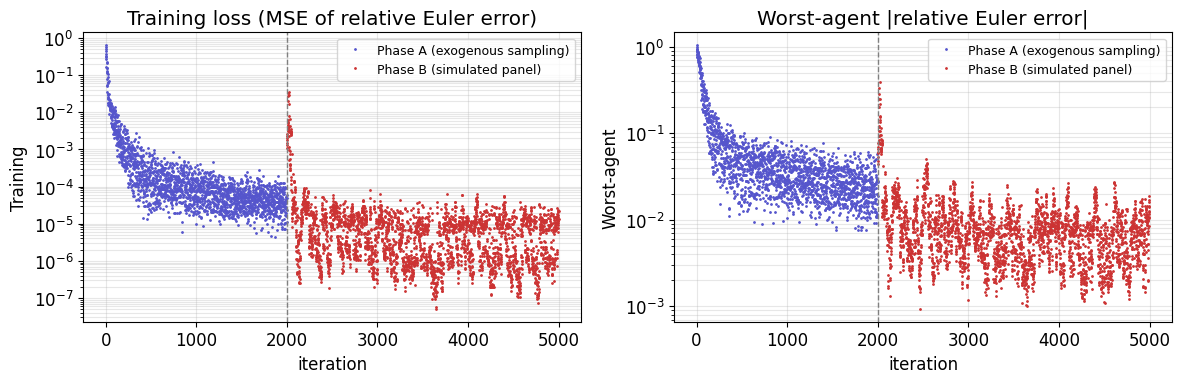


Final (last 200 iterations of Phase B):
  mean loss       = 7.163e-06
  mean max|REE|   = 7.882e-03
  median max|REE| = 7.374e-03

Success criterion: median max|REE| < 5e-2 and mean loss < 1e-3.
  --> PASS


In [11]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(N_TOTAL)
for ax, (y, title) in zip(
    axes,
    [(loss_history,    "Training loss (MSE of relative Euler error)"),
     (ree_max_history, "Worst-agent |relative Euler error|")],
):
    ax.semilogy(x[phase_history == 0], y[phase_history == 0], ".", markersize=2,
                color="#5555cc", label="Phase A (exogenous sampling)")
    ax.semilogy(x[phase_history == 1], y[phase_history == 1], ".", markersize=2,
                color="#cc3333", label="Phase B (simulated panel)")
    ax.axvline(N_PHASE_A, color="gray", ls="--", lw=1)
    ax.set_xlabel("iteration")
    ax.set_ylabel(title.split(" ")[0])
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

# Report post-training statistics (last 200 iterations of Phase B)
tail = slice(-200, None)
print(f"\nFinal (last 200 iterations of Phase B):")
print(f"  mean loss       = {loss_history[tail].mean():.3e}")
print(f"  mean max|REE|   = {ree_max_history[tail].mean():.3e}")
print(f"  median max|REE| = {np.median(ree_max_history[tail]):.3e}")
print(f"\nSuccess criterion: median max|REE| < 5e-2 and mean loss < 1e-3.")
pass_crit = (np.median(ree_max_history[tail]) < 5e-2) and (loss_history[tail].mean() < 1e-3)
print(f"  --> {'PASS' if pass_crit else 'did not fully converge; see notes below'}")


### 10.2 Ergodic behaviour of aggregate capital

During Phase B the panel visits a narrow range of aggregate capital
around the model's ergodic mean.  We plot $\bar K_t$ split by aggregate
state — it should be slightly higher in good times and lower in bad
times, consistent with standard RBC intuition.

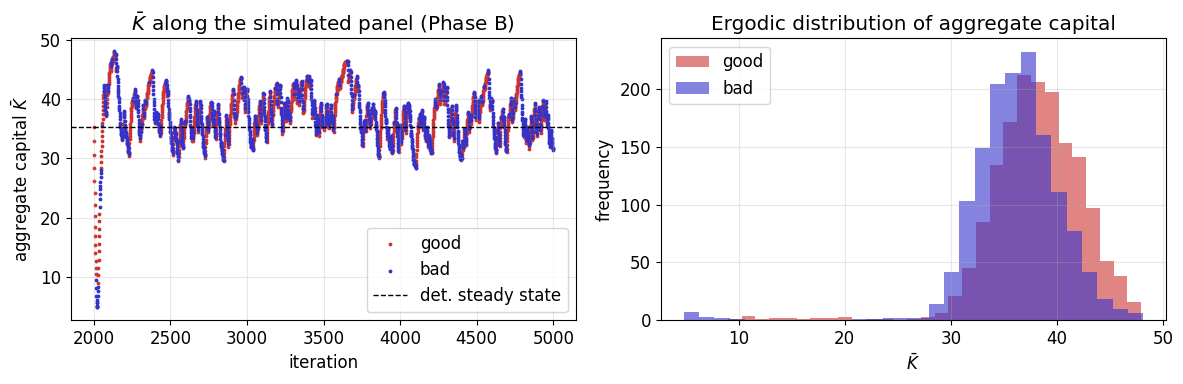

Good-state (Phase B):  mean K̄ = 38.09,  std = 4.485
Bad-state  (Phase B):  mean K̄ = 36.12,  std = 4.580
Deterministic steady state K* = 35.33


In [12]:

# Restrict to Phase B for ergodic analysis (the only phase with a real panel)
mask_B = (phase_history == 1)
K_B = K_history[mask_B]
a_B = a_history[mask_B]
t_B = np.where(mask_B)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(t_B[a_B == 1], K_B[a_B == 1], s=3, color="#cc3333", label="good")
axes[0].scatter(t_B[a_B == 0], K_B[a_B == 0], s=3, color="#3333cc", label="bad")
axes[0].axhline(K_SS, color="k", ls="--", lw=1, label="det. steady state")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel(r"aggregate capital $\bar K$")
axes[0].set_title(r"$\bar K$ along the simulated panel (Phase B)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(K_B[a_B == 1], bins=30, color="#cc3333", alpha=0.6, label="good")
axes[1].hist(K_B[a_B == 0], bins=30, color="#3333cc", alpha=0.6, label="bad")
axes[1].set_xlabel(r"$\bar K$")
axes[1].set_ylabel("frequency")
axes[1].set_title("Ergodic distribution of aggregate capital")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Good-state (Phase B):  mean K̄ = {K_B[a_B==1].mean():.2f},  std = {K_B[a_B==1].std():.3f}")
print(f"Bad-state  (Phase B):  mean K̄ = {K_B[a_B==0].mean():.2f},  std = {K_B[a_B==0].std():.3f}")
print(f"Deterministic steady state K* = {K_SS:.2f}")


### 10.3 Krusell–Smith approximate aggregation: $R^2$ of the law of motion

The KS (1998) finding is that a **log-linear** forecasting rule

$$
\log \bar K_{t+1} = A(a_t) + B(a_t)\log \bar K_t
$$

fits the simulated dynamics with $R^2 > 0.9999$ in the classical KS solve.  Our deep-learning
policy produces simulated $\bar K$ paths that, if the network has
converged, should satisfy approximate aggregation too: empirically
$R^2 > 0.99$ in both aggregate states (this run: $\approx 0.997$ in the bad
state, $\approx 0.9997$ in the good state), without any separate
forecasting-rule fit.

We compute $R^2$ by OLS on $(\log \bar K_t, \log \bar K_{t+1})$ separately
for each aggregate-state pair, using the Phase B trajectory only.

In [13]:

# Phase-B-only trajectory
burn = 500
mask_late = (phase_history == 1)
idx_B = np.where(mask_late)[0]
K_seq = K_history[idx_B][burn:]
a_seq = a_history[idx_B][burn:]

logK = np.log(K_seq)
logK_t  = logK[:-1]
logK_tp = logK[1:]
a_t_seq = a_seq[:-1]

print("Law-of-motion regressions  log K̄_t+1 = A(a) + B(a) log K̄_t:")
print("-" * 72)
for a_val, lbl in [(0, "bad state "), (1, "good state")]:
    m = (a_t_seq == a_val)
    if m.sum() < 20:
        continue
    x, y = logK_t[m], logK_tp[m]
    # polyfit returns (slope, intercept)
    slope, intercept = np.polyfit(x, y, deg=1)
    y_hat = slope * x + intercept
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2) + 1e-30)
    r2 = 1.0 - ss_res / ss_tot
    print(f"  {lbl}:   slope B = {slope:+.5f},  intercept A = {intercept:+.5f},"
          f"   R² = {r2:.6f}   (n = {m.sum()})")
print("-" * 72)
print("Krusell--Smith approximate-aggregation target:  R² >= 0.99")


Law-of-motion regressions  log K̄_t+1 = A(a) + B(a) log K̄_t:
------------------------------------------------------------------------
  bad state :   slope B = +0.97652,  intercept A = +0.07398,   R² = 0.996732   (n = 1172)
  good state:   slope B = +0.95569,  intercept A = +0.17001,   R² = 0.999667   (n = 1327)
------------------------------------------------------------------------
Krusell--Smith approximate-aggregation target:  R² >= 0.99


### 10.4 Learned savings policy

We plot the savings function $k'(k,\varepsilon,\bar K, a)$ for an employed
and an unemployed agent in each aggregate state.  Expected properties:

- Monotonically increasing in $k$.
- Employed agents save more than unemployed (higher income, more
  consumption-smoothing motive).
- In good times, higher wage pushes savings up.
- The $45°$ line represents "save everything".  An interior ergodic
  distribution requires that the policy curve crosses the $45°$ line.

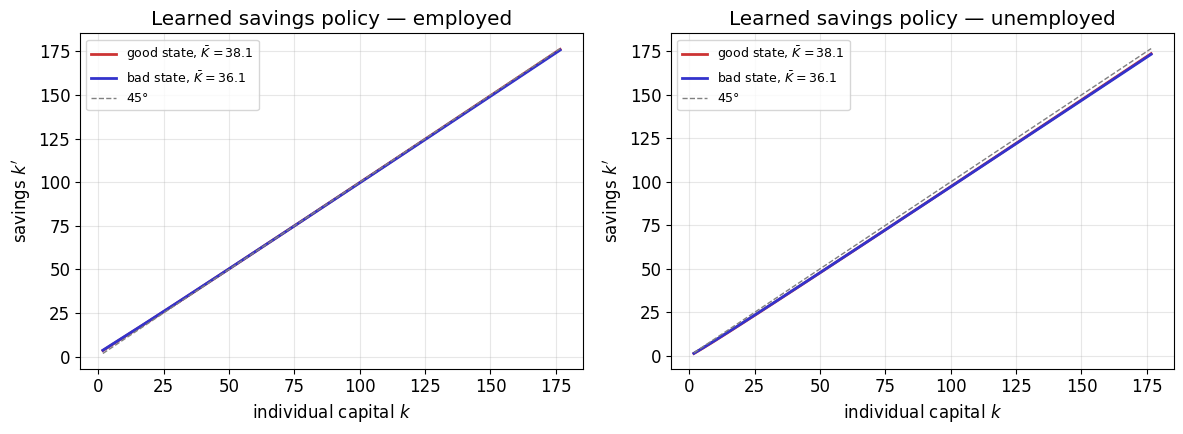

In [14]:

K_bar_good = K_B[a_B == 1].mean()
K_bar_bad  = K_B[a_B == 0].mean()

def eval_policy(k_grid, eps_int, K_agg, a_idx):
    N = len(k_grid)
    k_col    = k_grid.reshape(-1, 1)
    eps_1hot = np.tile(np.eye(2, dtype=np.float32)[eps_int], (N, 1))
    K_col    = np.full((N, 1), K_agg, dtype=np.float32)
    a_1hot   = np.tile(np.eye(2, dtype=np.float32)[a_idx], (N, 1))
    phi = policy_net([k_col, eps_1hot, K_col, a_1hot], training=False).numpy().flatten()
    z_val = z_levels[a_idx].numpy()
    u_val = u_rates[a_idx].numpy()
    L_val = 1.0 - u_val
    w = (1.0 - alpha.numpy()) * z_val * K_agg**alpha.numpy()     * L_val**(-alpha.numpy())
    r = alpha.numpy()         * z_val * K_agg**(alpha.numpy()-1) * L_val**(1.0 - alpha.numpy())
    y = w * float(l_bar.numpy()) * eps_int + (1.0 + r - float(delta.numpy())) * k_grid
    k_next = (1.0 - phi) * y
    c      = phi * y
    return phi, c, k_next, w, r

k_grid = np.linspace(0.05 * K_SS, 5.0 * K_SS, 200).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (eps_int, lbl) in zip(axes, [(1, "employed"), (0, "unemployed")]):
    _, _, kp_g, _, _ = eval_policy(k_grid, eps_int, K_bar_good, 1)
    _, _, kp_b, _, _ = eval_policy(k_grid, eps_int, K_bar_bad,  0)
    ax.plot(k_grid, kp_g, color="#cc3333", lw=2, label=rf"good state, $\bar K = {K_bar_good:.1f}$")
    ax.plot(k_grid, kp_b, color="#3333cc", lw=2, label=rf"bad state, $\bar K = {K_bar_bad:.1f}$")
    ax.plot(k_grid, k_grid, color="gray", ls="--", lw=1, label=r"$45°$")
    ax.set_xlabel("individual capital $k$")
    ax.set_ylabel("savings $k'$")
    ax.set_title(f"Learned savings policy — {lbl}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Summary and validation checklist

**Success criteria** for a classroom-scale solve:

- [ ] Median max $|\text{REE}|$ over the last 200 Phase-B iterations is below
      $5\times 10^{-2}$ (not quite the 1% target of the MMW paper — that
      takes longer training and larger networks — but economically
      meaningful).
- [ ] Mean loss over the last 200 Phase-B iterations is below $10^{-3}$.
- [ ] $\bar K$ trajectory is stationary and clearly bimodal in the
      aggregate state.
- [ ] Log-linear KS forecasting rule fitted ex post to the simulated path
      has $R^2 > 0.99$ in both aggregate states.
- [ ] Savings policy is monotone in $k$, crosses the $45°$ line, and
      employed $>$ unemployed.

### If something doesn't converge

1. Increase `N_PHASE_A` from 2000 to 3000 — more uniform-sampling warm-up
   gives a better global policy before the ergodic phase starts.
2. Increase `N_AGENTS` (e.g. to 500) — reduces Monte Carlo noise in the
   per-iteration mean-squared residual.
3. Lower `LR_MAX` from $10^{-3}$ to $5 \times 10^{-4}$ if you see
   oscillations in Phase B.
4. Change the initial panel: sample $k_i$ from $\text{Unif}[0.5 K^*, 1.5 K^*]$
   rather than initialising every agent at the same point.

### Next steps

- Histogram-DEQN alternative: `11_Continuum_of_Agents_DEQN.ipynb`
  (Azinovic–Gaegauf–Scheidegger 2022 Appendix A.5).
- Production-scale all-in-one DL for KS:
  [marcmaliar/deep-learning-euler-method-krusell-smith](https://github.com/marcmaliar/deep-learning-euler-method-krusell-smith).
- DeepHAM (learned generalized moments):
  Han, Yang & E (*Quantitative Economics*, forthcoming);
  preprint `../readings/DeepHAM_Han_Yang_E_2023.pdf`.